# AO3 Hockey Fanfiction Analysis: The "Heated Rivalry" Effect

This notebook explores the growth and evolution of hockey fanfiction on Archive of Our Own (AO3) and its relationship to the release of the television adaptation of Rachel Reid's **Heated Rivalry** (premiered on HBO Max on **November 28, 2025**).

We will visualize:

1. **Fandom Streamgraph (Time Graphic)**: A streamgraph showing the volume of works across grouped overarching fandom categories from 2014 to 2026.
2. **Interactive Zoomable Fandom Bubble Chart**: A client-side interactive packed bubble chart where clicking on a bubble drills down into its subcategories.
3. **Fandom Overarching Tag Breakdowns**: A side-by-side breakdown of the subcategories that make up the main *Hockey RPF* and *Heated Rivalry* tags.
4. **Trope & Character Tag Network**: A network graph exploring co-occurrences of popular tropes and relationship tags (e.g. *Enemies to Lovers*, *Mutual Pining*).

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import networkx as nx
import textwrap
import json as json_lib
import itertools
from collections import Counter
from IPython.display import HTML

# Set style for premium visualizations
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

## 1. Load and Prepare Data

We load the database, filter for years 2014 to 2026, and apply our classification logic to group raw fandom tags into overarching categories:
- **Hockey RPF**: Combines general Hockey RPF, Men's Hockey RPF, and Women's Hockey RPF.
- **Heated Rivalry**: Combines Heated Rivalry (TV), the Game Changers book series, and fics tagged with both.

In [2]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("hockey_fic.db")
df = pd.read_sql_query("SELECT published, fandoms, tags FROM works;", conn)
conn.close()

# Parse dates
df['published_dt'] = pd.to_datetime(df['published'], errors='coerce')
df['year'] = df['published_dt'].dt.year

# Filter timeline
df_filtered = df[(df['year'] >= 2014) & (df['year'] <= 2026)].copy()

# Define classification logic
def classify_fandom(fandom_str):
    if not fandom_str:
        return "Other Fandoms"
    f_lower = fandom_str.lower()
    if "heated rivalry" in f_lower or "game changers" in f_lower or "rachel reid" in f_lower:
        return "Heated Rivalry"
    if "hockey rpf" in f_lower or "hockey rps" in f_lower:
        return "Hockey RPF"
    if "check please!" in f_lower:
        return "Check Please! (Webcomic)"
    if "original work" in f_lower:
        return "Original Work"
    if "harry potter" in f_lower:
        return "Harry Potter"
    return "Other Fandoms"

df_filtered['grouped_fandom'] = df_filtered['fandoms'].apply(classify_fandom)
print(df_filtered['grouped_fandom'].value_counts())

grouped_fandom
Hockey RPF                  5175
Other Fandoms               2953
Heated Rivalry              1330
Check Please! (Webcomic)     578
Original Work                191
Harry Potter                 175
Name: count, dtype: int64


## 2. Fandom Volume Over Time: Streamgraph

We draw the streamgraph of these grouped categories over time. Notice how the combined streams show a highly clean, organic flow shape, showcasing the clear transition of focus to the `Heated Rivalry` group after the TV show premiere in late 2025.

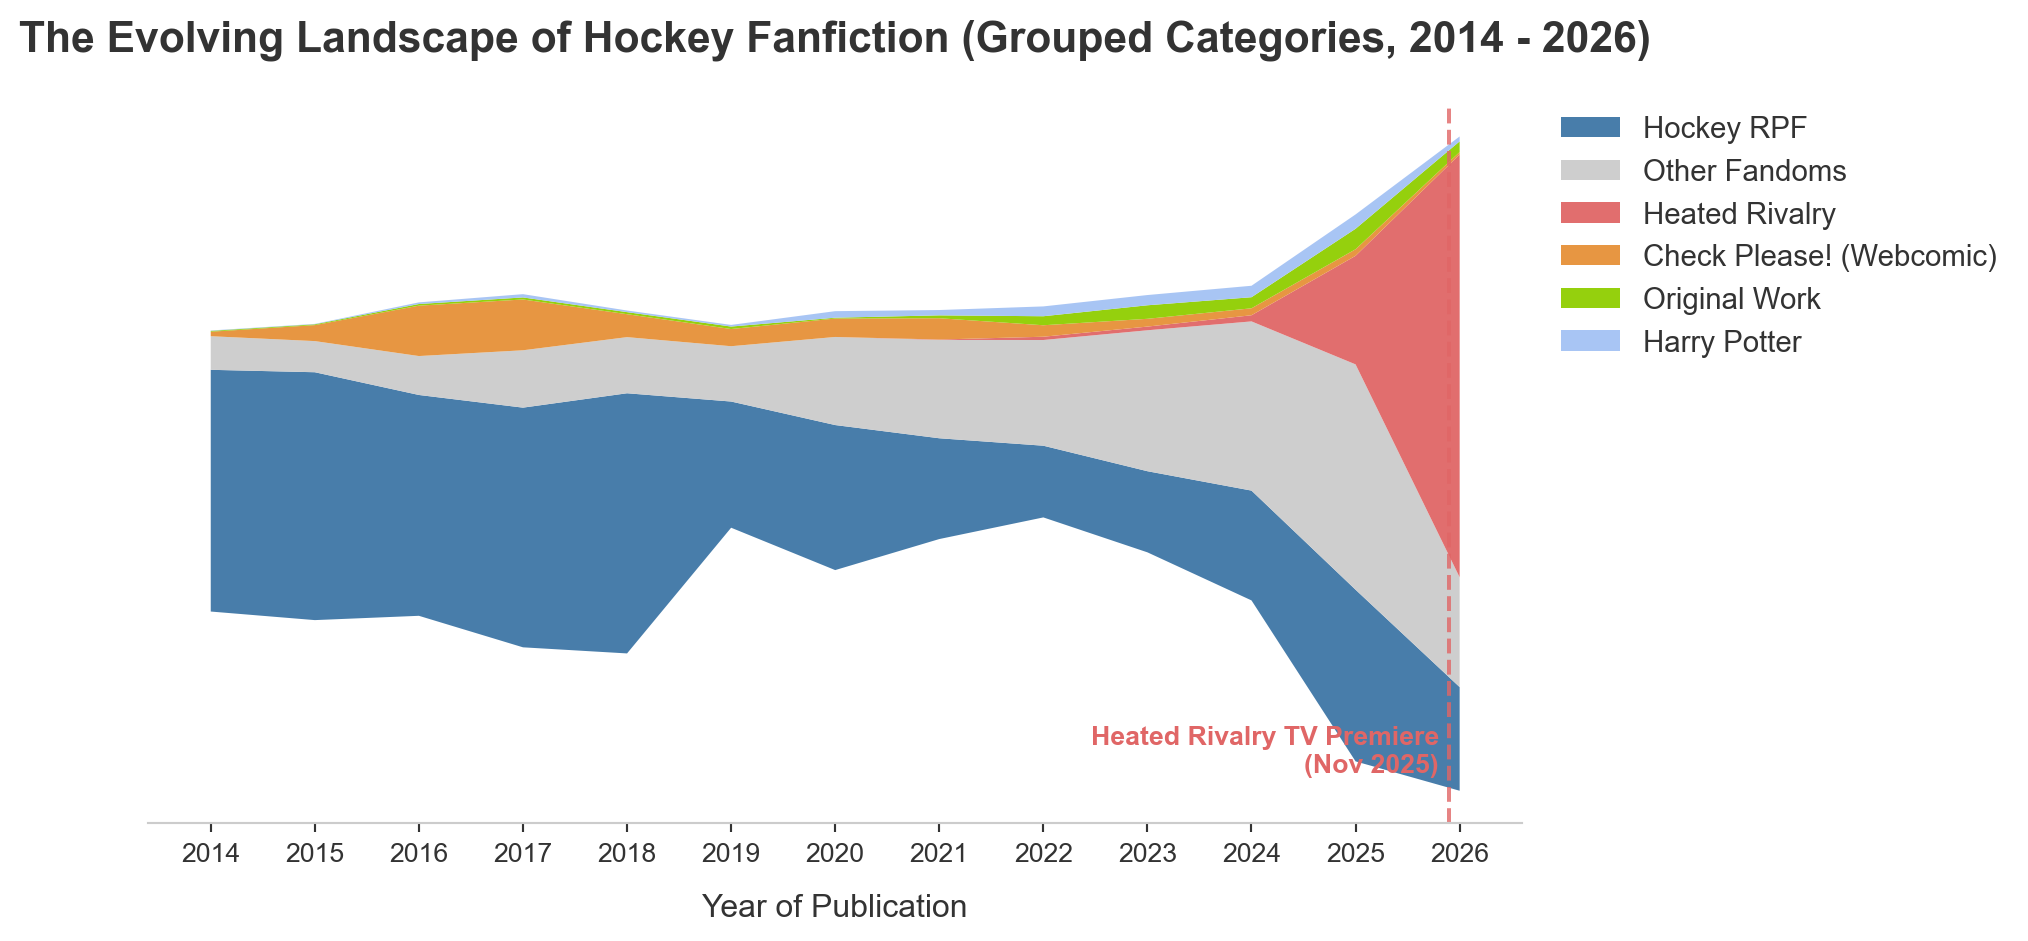

In [3]:
# Set up group order and colors
top_groups = ["Hockey RPF", "Other Fandoms", "Heated Rivalry", "Check Please! (Webcomic)", "Original Work", "Harry Potter"]
colors = [
    '#3e76a6', # Hockey RPF (Ice Blue)
    '#cccccc', # Other Fandoms (Muted Grey)
    '#e06666', # Heated Rivalry (Warm Coral/Red)
    '#e69138', # Check Please! (Orange)
    '#8fce00', # Original Work (Muted Green)
    '#a4c2f4'  # Harry Potter (Soft Blue)
]

# Prepare yearly data
years = list(range(2014, 2027))
yearly_data = []
for g in top_groups:
    counts = [len(df_filtered[(df_filtered['year'] == y) & (df_filtered['grouped_fandom'] == g)]) for y in years]
    yearly_data.append(counts)

y_matrix = np.array(yearly_data)

# Plot
#| fig-width: 10
#| fig-height: 5
#| fig-align: center
plt.figure(figsize=(10, 5))
plt.stackplot(years, y_matrix, labels=top_groups, baseline='wiggle', colors=colors, alpha=0.95)

# Style
plt.title("The Evolving Landscape of Hockey Fanfiction (Grouped Categories, 2014 - 2026)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Year of Publication", fontsize=12, labelpad=10)
plt.xticks(years, fontsize=10)
plt.yticks([])  # Hide y-axis since relative stream shape is what matters

ax = plt.gca()
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

# Draw vertical indicator line for Heated Rivalry TV Premiere (Nov 2025)
plt.axvline(x=2025.9, color='#e06666', linestyle='--', linewidth=1.5, alpha=0.8)
plt.text(2025.8, plt.ylim()[0] * 0.9, 'Heated Rivalry TV Premiere\n(Nov 2025)', 
         color='#e06666', fontsize=10, fontweight='bold', ha='right', va='bottom')

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

## 3. Fandom Share: Static Packed Bubble Chart

This static bubble chart is generated using python's `matplotlib` and `circlify` libraries. It shows a packed circle packing visualization of fandoms and subcategories.

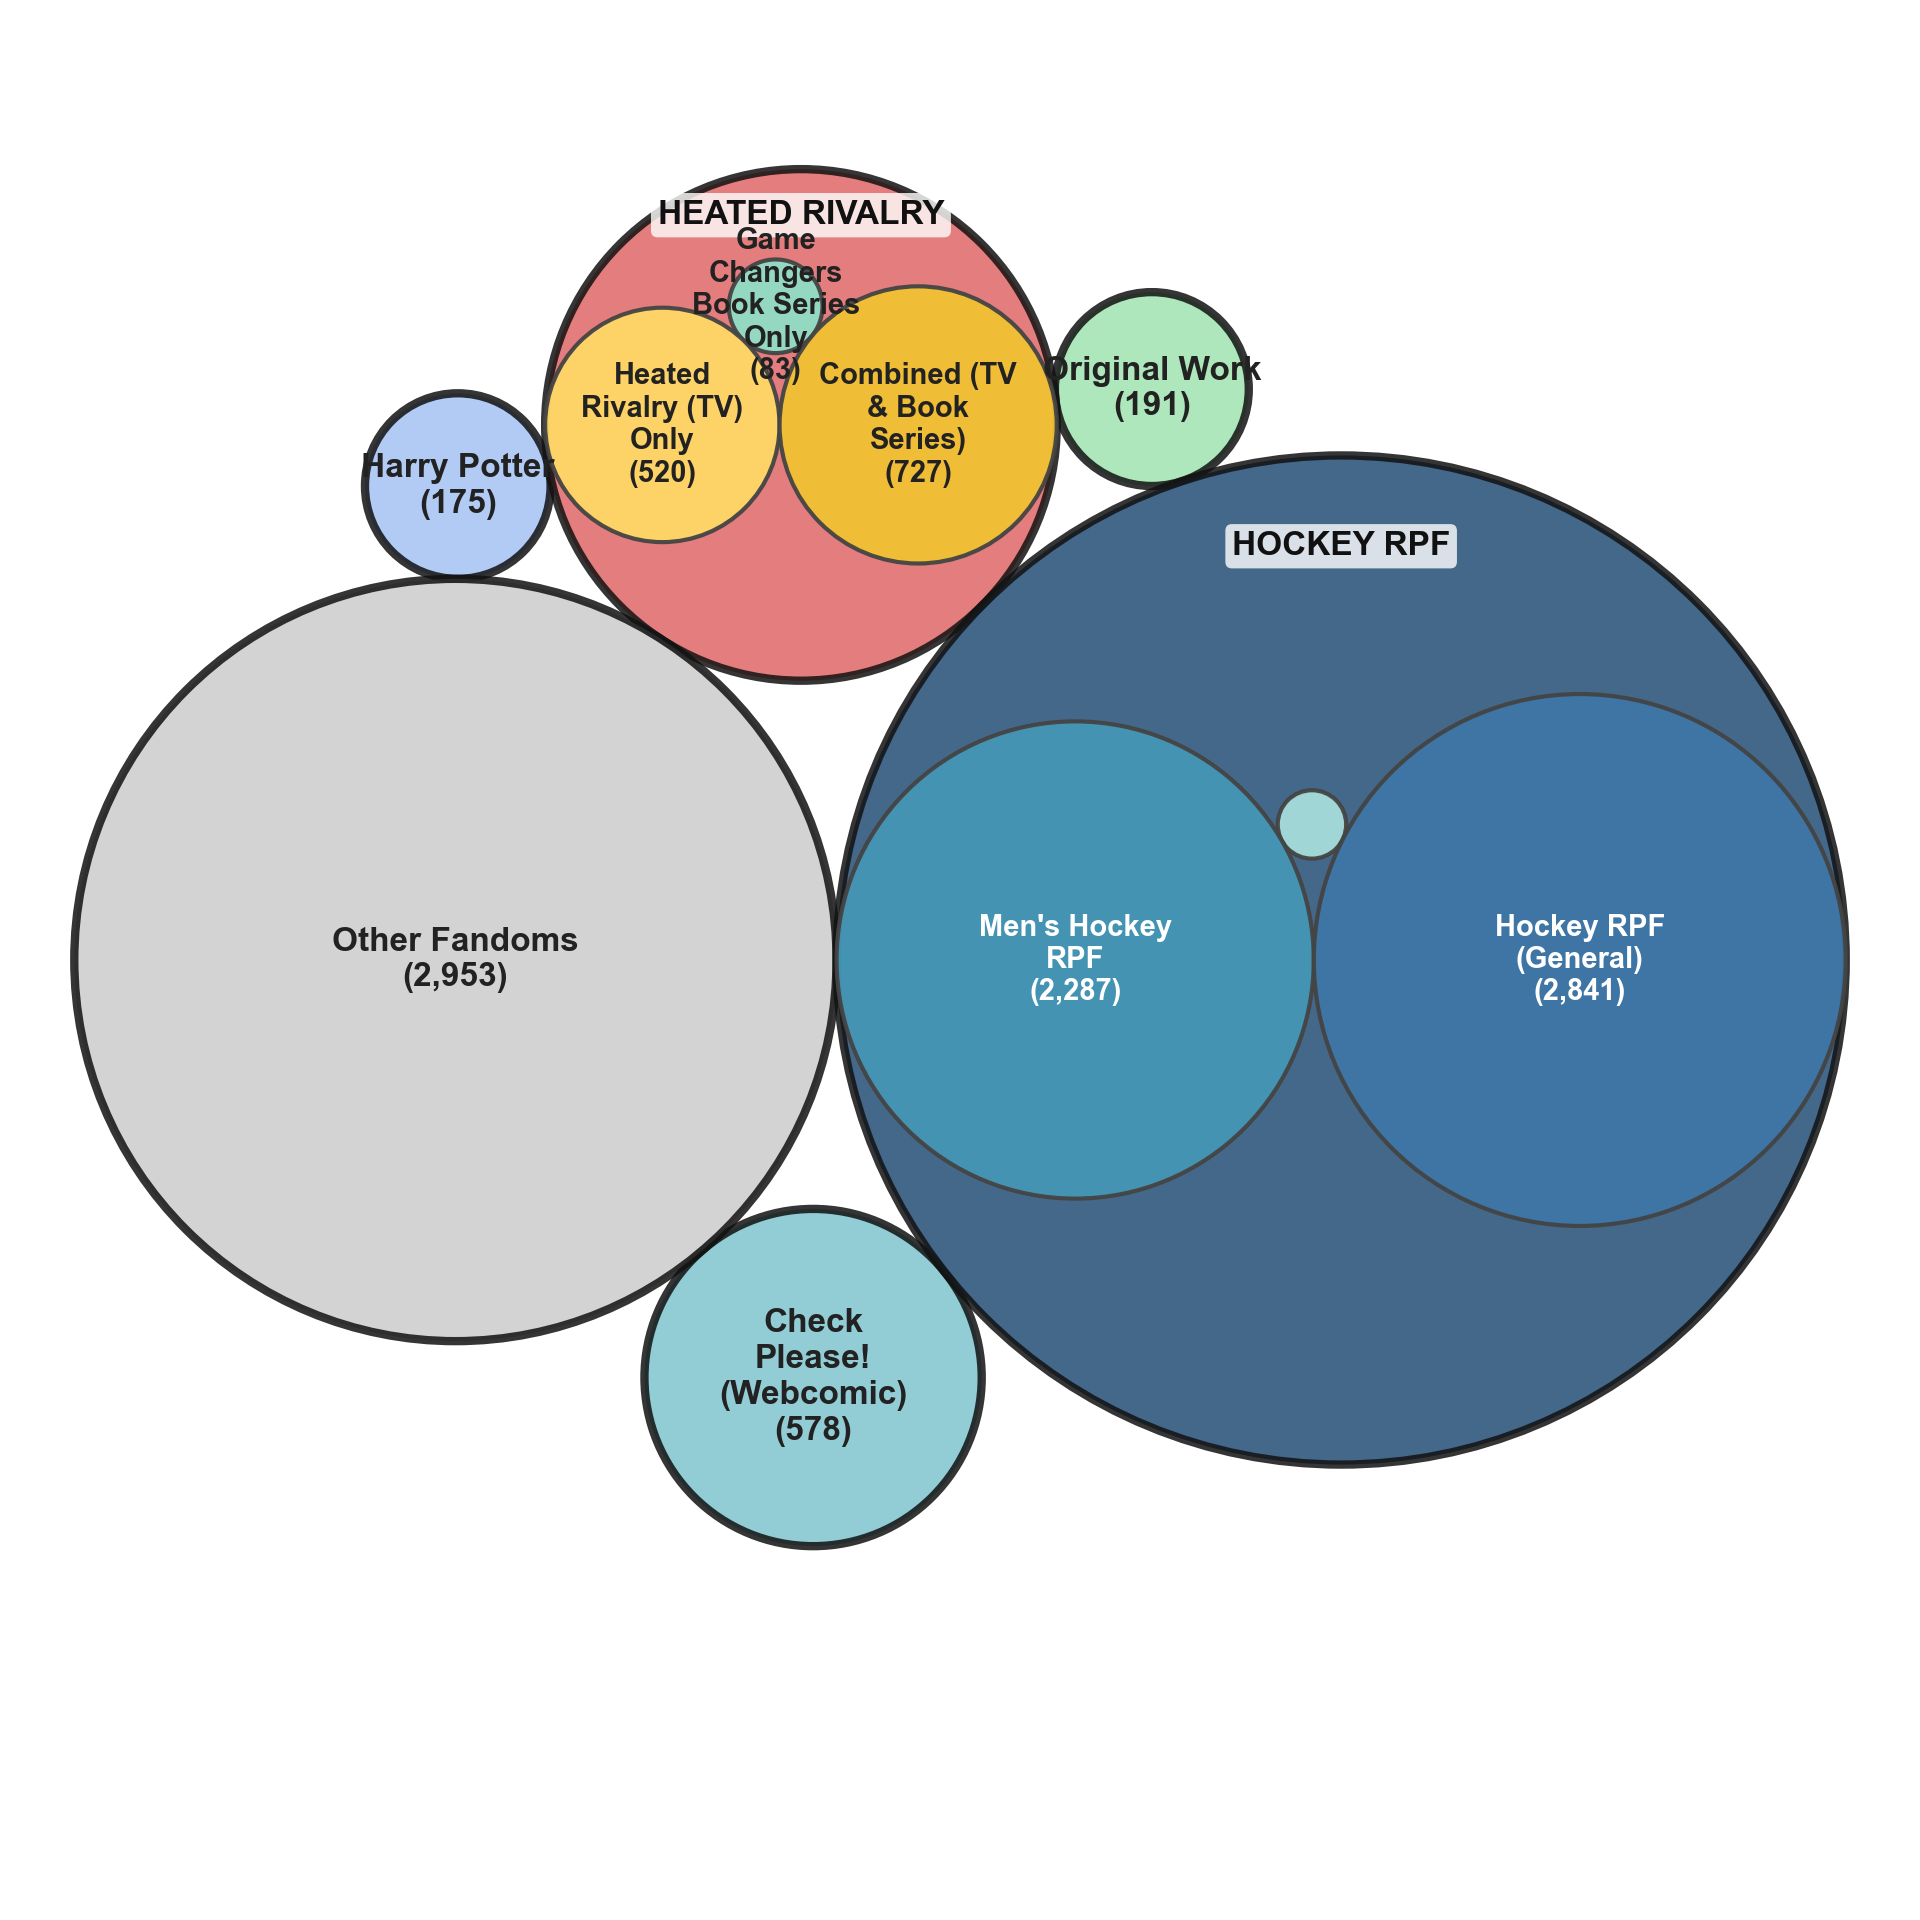

In [4]:
# Subclassification definitions for hierarchy
def subclassify_hockey_rpf(fdom):
    f_lower = fdom.lower()
    if "women's hockey rpf" in f_lower: return "Women's Hockey RPF"
    if "men's hockey rpf" in f_lower: return "Men's Hockey RPF"
    return "Hockey RPF (General)"

def subclassify_heated_rivalry(fdom):
    f_lower = fdom.lower()
    has_tv = "tv" in f_lower
    has_book = "game changers" in f_lower or "rachel reid" in f_lower or "book" in f_lower
    if has_tv and has_book: return "Combined (TV & Book Series)"
    if has_tv: return "Heated Rivalry (TV) Only"
    return "Game Changers Book Series Only"

rpf_sub_counts = {}
hr_sub_counts = {}
check_please_val = 0
original_work_val = 0
harry_potter_val = 0
other_fandoms_val = 0

for f in df_filtered['fandoms']:
    f_lower = str(f).lower()
    if "heated rivalry" in f_lower or "game changers" in f_lower or "rachel reid" in f_lower:
        sub = subclassify_heated_rivalry(f)
        hr_sub_counts[sub] = hr_sub_counts.get(sub, 0) + 1
    elif "hockey rpf" in f_lower or "hockey rps" in f_lower:
        sub = subclassify_hockey_rpf(f)
        rpf_sub_counts[sub] = rpf_sub_counts.get(sub, 0) + 1
    elif "check please!" in f_lower:
        check_please_val += 1
    elif "original work" in f_lower:
        original_work_val += 1
    elif "harry potter" in f_lower:
        harry_potter_val += 1
    else:
        other_fandoms_val += 1

# Prepare data for circlify
import circlify
import matplotlib.pyplot as plt

data = [
    {
        'id': 'Hockey RPF',
        'datum': sum(rpf_sub_counts.values()),
        'children': [{'id': k, 'datum': v} for k, v in rpf_sub_counts.items()]
    },
    {
        'id': 'Heated Rivalry',
        'datum': sum(hr_sub_counts.values()),
        'children': [{'id': k, 'datum': v} for k, v in hr_sub_counts.items()]
    },
    {'id': 'Check Please! (Webcomic)', 'datum': check_please_val},
    {'id': 'Original Work', 'datum': original_work_val},
    {'id': 'Harry Potter', 'datum': harry_potter_val},
    {'id': 'Other Fandoms', 'datum': other_fandoms_val}
]

# Run circlify
circles = circlify.circlify(data)

# Set styles for premium visualization
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

color_map = {
    "Hockey RPF": "#234d75",
    "Other Fandoms": "#cccccc",
    "Heated Rivalry": "#e06666",
    "Check Please! (Webcomic)": "#7fc4ce",
    "Original Work": "#a1e3b1",
    "Harry Potter": "#a4c2f4"
}

sub_color_map = {
    "Hockey RPF (General)": "#3e76a6",
    "Men's Hockey RPF": "#4596b5",
    "Women's Hockey RPF": "#a6dedb",
    "Combined (TV & Book Series)": "#f1c232",
    "Heated Rivalry (TV) Only": "#ffd966",
    "Game Changers Book Series Only": "#91dec6"
}

# Create figure
#| fig-width: 6.5
#| fig-height: 6.5
#| fig-align: center
fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=150)
ax.set_aspect('equal')
ax.axis('off')

# Sort circles by level (level 1 first so we draw outer circles before inner)
circles_sorted = sorted(circles, key=lambda c: c.level)

# Find boundaries to set limits
lim = max([max(abs(circle.x) + circle.r, abs(circle.y) + circle.r) for circle in circles])
ax.set_xlim(-lim * 1.05, lim * 1.05)
ax.set_ylim(-lim * 1.05, lim * 1.05)

# Draw circles and add labels
for circle in circles_sorted:
    label = circle.ex.get('id')
    level = circle.level
    
    if level == 1:
        color = color_map.get(label, "#cccccc")
        alpha = 0.85
        edgecolor = "#111111"
        linewidth = 2.0
    else:
        color = sub_color_map.get(label, "#e1eedd")
        alpha = 0.95
        edgecolor = "#444444"
        linewidth = 1.0
        
    # Draw circle
    circ_patch = plt.Circle(
        (circle.x, circle.y), 
        circle.r, 
        facecolor=color, 
        edgecolor=edgecolor, 
        linewidth=linewidth, 
        alpha=alpha
    )
    ax.add_patch(circ_patch)
    
    # Text color contrast
    if color in ["#234d75", "#3e76a6", "#4596b5"]:
        text_color = "white"
    else:
        text_color = "#222222"
        
    # Labeling
    if circle.r > 0.04:
        has_children = 'children' in circle.ex
        if has_children:
            # Group label at the top of the circle to not clash with children in the center
            ax.text(
                circle.x, 
                circle.y + circle.r * 0.82, 
                label.upper(), 
                ha='center', 
                va='center', 
                fontsize=8, 
                fontweight='bold', 
                color='#111111',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2')
            )
        else:
            val = circle.ex.get('datum')
            display_text = f"{label}\n({val:,})"
            if len(label) > 15:
                import textwrap
                wrapped_label = "\n".join(textwrap.wrap(label, width=12))
                display_text = f"{wrapped_label}\n({val:,})"
                
            ax.text(
                circle.x, 
                circle.y, 
                display_text, 
                ha='center', 
                va='center', 
                fontsize=7 if level==2 else 8, 
                fontweight='bold', 
                color=text_color
            )

plt.tight_layout()
plt.show()

## 4. Fandom Overarching Tag Breakdowns

Here we break down the two main grouped categories to see their subcategory distribution. 
- **Hockey RPF** is divided into Men's Hockey RPF, Women's Hockey RPF, and general/generic Hockey RPF.
- **Heated Rivalry** is divided into fics focusing solely on the TV show, fics tagged with the book series, and fics tagged with both.

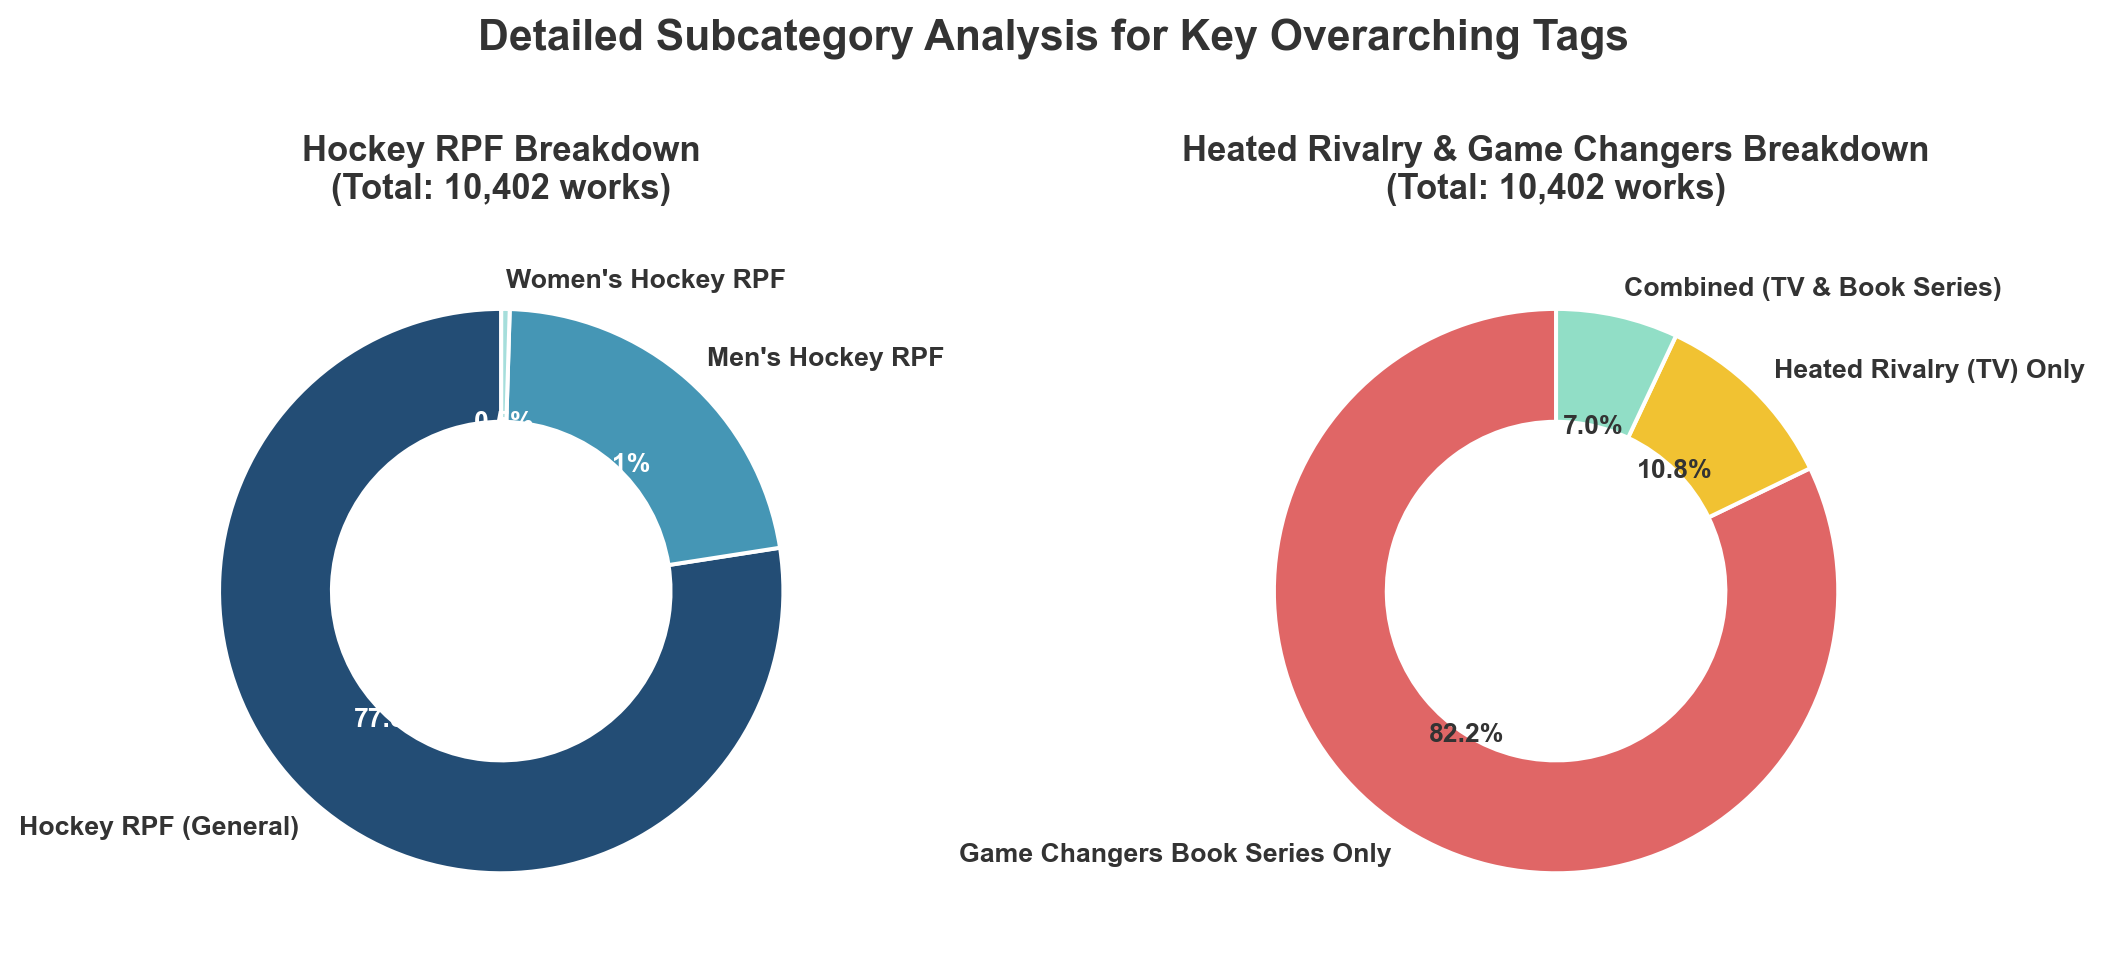

In [5]:
df_filtered['sub_rpf'] = df_filtered['fandoms'].apply(subclassify_hockey_rpf)
df_filtered['sub_hr'] = df_filtered['fandoms'].apply(subclassify_heated_rivalry)

rpf_counts = df_filtered['sub_rpf'].value_counts()
hr_counts = df_filtered['sub_hr'].value_counts()

# Plot side-by-side Donut Charts
#| fig-width: 11
#| fig-height: 5.5
#| fig-align: center
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5))

# Palette mapping
rpf_colors = ['#234d75', '#4596b5', '#a6dedb']
hr_colors = ['#e06666', '#f1c232', '#91dec6']

# Donut 1: Hockey RPF Breakdown
wedges1, texts1, autotexts1 = ax1.pie(
    rpf_counts, 
    labels=rpf_counts.index, 
    autopct='%1.1f%%',
    startangle=90, 
    colors=rpf_colors,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=1.5),
    textprops=dict(color="#333333", fontweight='bold')
)
plt.setp(autotexts1, size=10, weight="bold", color="white" if rpf_colors[0] == '#234d75' else "#333333")
ax1.set_title(f"Hockey RPF Breakdown\n(Total: {rpf_counts.sum():,} works)", fontsize=13, fontweight='bold', pad=15)

# Donut 2: Heated Rivalry Breakdown
wedges2, texts2, autotexts2 = ax2.pie(
    hr_counts, 
    labels=hr_counts.index, 
    autopct='%1.1f%%',
    startangle=90, 
    colors=hr_colors,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=1.5),
    textprops=dict(color="#333333", fontweight='bold')
)
plt.setp(autotexts2, size=10, weight="bold", color="#333333")
ax2.set_title(f"Heated Rivalry & Game Changers Breakdown\n(Total: {hr_counts.sum():,} works)", fontsize=13, fontweight='bold', pad=15)

plt.suptitle("Detailed Subcategory Analysis for Key Overarching Tags", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 5. Trope & Character Tag Network

To analyze the thematic elements of these fics, we map the relationships between popular tropes and relationship-specific tags. 

We calculate co-occurrences of tags appearing in the same work, filtering for associations appearing in **at least 60 works** to isolate the core thematic network and avoid a cluttered hairball.

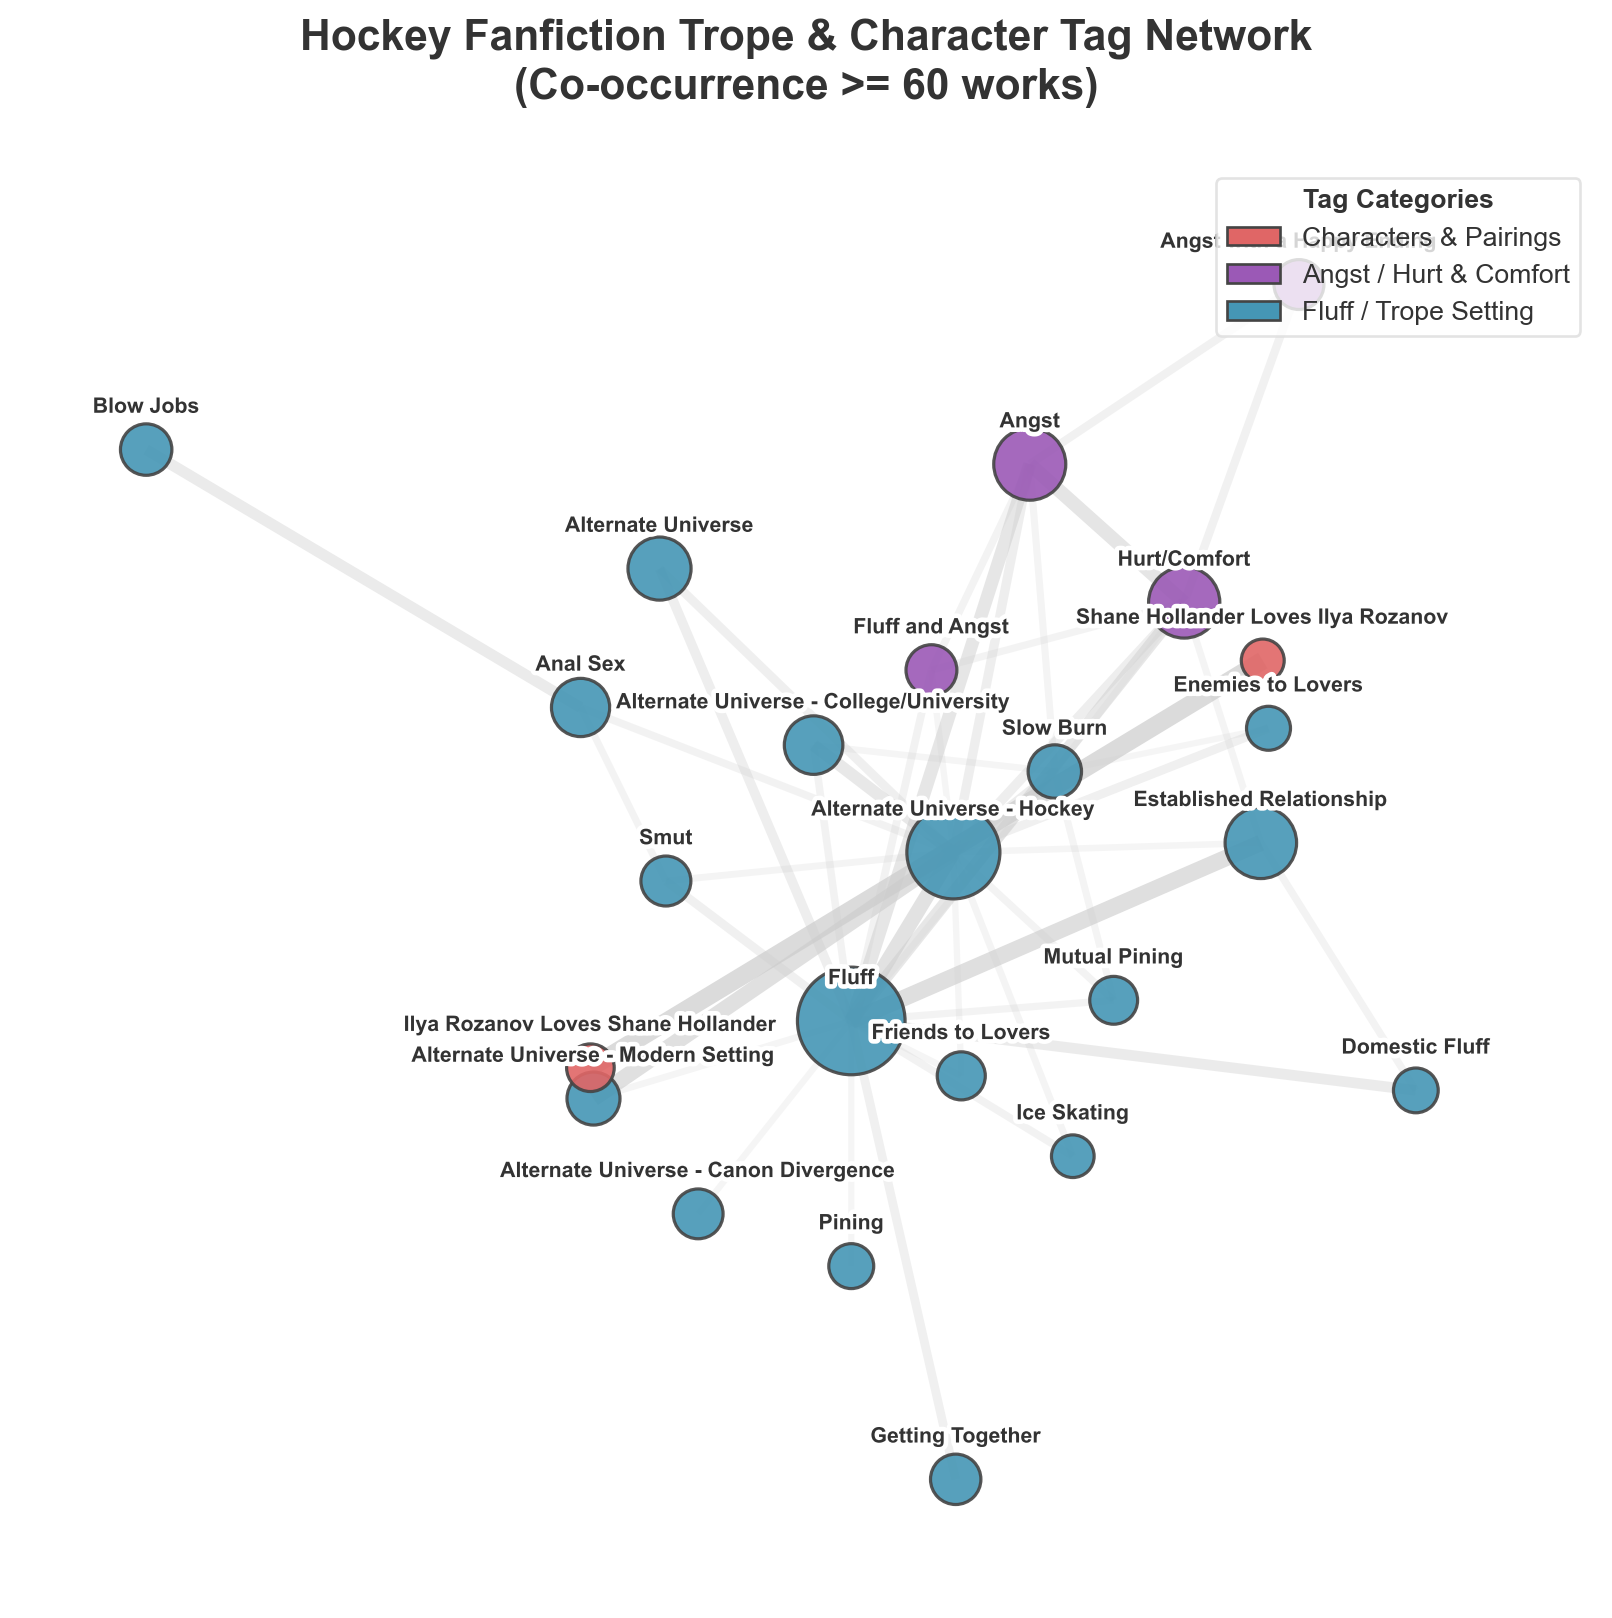

In [6]:
# Parse tags
tag_lists = []
for tags_json in df['tags'].dropna():
    try:
        tags = [t.strip() for t in json_lib.loads(tags_json)]
        tag_lists.append(tags)
    except:
        pass

# Count tag frequencies
all_tags = list(itertools.chain(*tag_lists))
tag_counts = Counter(all_tags)

# Exclude generic structural and fandom tags to focus on tropes
exclude_tags = {
    "Hockey", "Hockey RPF", "Men's Hockey RPF", "Sports RPF", "RPS", "RPF", 
    "Sports", "Rivalry", "Slash", "F/M", "M/M", "Podfic"
}

# Select the top 25 most frequent trope/character tags
filtered_top_tags = []
for tag, count in tag_counts.most_common(100):
    if tag not in exclude_tags and len(filtered_top_tags) < 25:
        filtered_top_tags.append(tag)

# Build NetworkX Graph
G = nx.Graph()
for tag in filtered_top_tags:
    G.add_node(tag, count=tag_counts[tag])

# Calculate co-occurrences
co_occur = Counter()
for tags in tag_lists:
    selected_in_work = [t for t in tags if t in filtered_top_tags]
    if len(selected_in_work) > 1:
        for p1, p2 in itertools.combinations(sorted(selected_in_work), 2):
            co_occur[(p1, p2)] += 1

# Add edges above threshold 60
for (p1, p2), weight in co_occur.items():
    if weight >= 60:
        G.add_edge(p1, p2, weight=weight)

# Remove isolate nodes for clean layout
isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)

# Plot the network
#| fig-width: 8.5
#| fig-height: 8.5
#| fig-align: center
plt.figure(figsize=(8.5, 8.5))

# Kamada-Kawai layout spaces out clusters and components naturally
pos = nx.kamada_kawai_layout(G)

# Node sizes and color map based on category
node_sizes = [G.nodes[n]['count'] * 1.0 for n in G.nodes()]

node_colors = []
for n in G.nodes():
    if "Shane" in n or "Ilya" in n or "Heated Rivalry" in n:
        node_colors.append('#e06666') # Warm Coral (Characters)
    elif "Angst" in n or "Hurt" in n:
        node_colors.append('#9b59b6') # Purple (Angst / Hurt)
    else:
        node_colors.append('#4596b5') # Ice Teal (Fluff / Tropes)

# Normalize edge weights for width and opacity
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
max_w = max(weights) if weights else 1
edge_widths = [(w / max_w) * 6 + 0.8 for w in weights]
edge_alphas = [max(0.15, min(w / max_w * 0.7, 0.7)) for w in weights]

# Draw network elements
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, 
                       alpha=0.9, edgecolors='#444444', linewidths=1.2)

for (u, v), width, alpha in zip(edges, edge_widths, edge_alphas):
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width, 
                           edge_color='#cccccc', alpha=alpha)

# Set custom limits with padding to avoid legend overlap
x_vals = [p[0] for p in pos.values()]
y_vals = [p[1] for p in pos.values()]
x_min, x_max = min(x_vals), max(x_vals)
y_min, y_max = min(y_vals), max(y_vals)
x_pad = (x_max - x_min) * 0.1
y_pad = (y_max - y_min) * 0.1
plt.xlim(x_min - x_pad, x_max + x_pad * 1.4)
plt.ylim(y_min - y_pad, y_max + y_pad)

# Draw labels with white outline paths for maximum legibility
for node, (x, y) in pos.items():
    try:
        clean_label = node.encode().decode('unicode-escape')
    except:
        clean_label = node
        
    txt = plt.text(x, y + 0.04, clean_label, fontsize=8, ha='center', va='bottom', 
                   fontweight='bold', color='#333333')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=3.5, foreground='white'),
        path_effects.Normal()
    ])

# Draw Legend (Key)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e06666', edgecolor='#444444', label='Characters & Pairings'),
    Patch(facecolor='#9b59b6', edgecolor='#444444', label='Angst / Hurt & Comfort'),
    Patch(facecolor='#4596b5', edgecolor='#444444', label='Fluff / Trope Setting')
]
plt.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10, 
           facecolor='white', edgecolor='#dddddd', title='Tag Categories', 
           title_fontproperties={'weight': 'bold'})

plt.title("Hockey Fanfiction Trope & Character Tag Network\n(Co-occurrence >= 60 works)", 
          fontsize=16, fontweight='bold', pad=25)
plt.axis('off')
plt.tight_layout()
plt.show()

## 6. What Happened in 2024? The Fandom Baseline Shift

Before the massive TV show explosion in late 2025, our data show a moderate but noticeable rise in hockey fics during **2024** (jumping from **628 fics in 2023 to 768 fics in 2024**).

Is this due to the release of the book *Game Changers*? Actually, no! The publishing dates tell a different story:
- *Game Changers* (Book 1) was published in **2018**.
- *Heated Rivalry* (Book 2) was published in **March 2019**.
- *The Long Game* (Shane and Ilya's sequel) was published in **April 2022**.

Three primary cultural factors explain the 2024 baseline shift:

1. **The BookTok "Hockey Romance" Wave**: Throughout 2023 and 2024, hockey romance became a massive viral sensation on TikTok. Driven by Hannah Grace's *Icebreaker* (released in late 2022 but dominating social media throughout 2023 and 2024), millions of new readers were introduced to the "hockey player romance" trope, bringing a huge influx of fans into AO3's hockey fanfiction space.
2. **Pre-Production Rumors & Option Hype**: Jacob Tierney contacted Rachel Reid to option the series in late 2023, and development/screenwriting took place throughout 2024. Casting discussions and pre-production rumors circulated in online romance spaces, generating early excitement and prompting authors to write fics before the TV show's formal release in 2025.
3. **Social Media Growth of Real-Life NHL RPF**: Real-life hockey fan communities (NHL RPF) experienced massive growth on social media platforms like Tumblr, Twitter, and TikTok in 2023-2024. In our database, general Hockey RPF tags jumped from 184 fics in 2023 to 246 in 2024, increasing the baseline volume of hockey fics overall.

## 7. Key Insights

- **Tagging Paradigms**: The streamgraph shows a major transition in fandom tags between 2018 and 2019, where `["Hockey RPF"]` was replaced by `["Men's Hockey RPF"]` as the primary classification on AO3.
- **The TV Show Boom**: The TV series premiere of *Heated Rivalry* in late November 2025 created a massive surge of new works, visible in the dramatic expansion at the right end of the streamgraph (late 2025 and 2026).
- **Fandom Share**: While the *Heated Rivalry (TV)* tags are growing rapidly, the historical corpus is still dominated by the broader `["Hockey RPF"]` and `["Men's Hockey RPF"]` categories.
- **Subcategory Insights**: Breaking down the combined tags reveals that the general/older tagging conventions represent the largest share of Hockey RPF, but the TV adaptation of Heated Rivalry has caused a huge surge in fics that reference both the TV show and Rachel Reid's original book series.
- **Thematic Clusters**: The network graph shows clear thematic sub-communities. We see an **Angst and Hurt/Comfort** cluster (purple nodes), a **Romance and Relationship** cluster (right-side teal nodes), and a **Sex/Smut** cluster (left-side teal nodes). The central hubs of the network remain `Fluff` and `Alternate Universe - Hockey`.